# Medical Billing Payment Status Prediction

## Overview
This project analyzes healthcare data to predict payment status (Paid, Pending, Failed) for medical bills. The dataset includes information on treatments, patients, doctors, appointments, and billing records.

In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/hospital-management-dataset/appointments.csv
/kaggle/input/hospital-management-dataset/billing.csv
/kaggle/input/hospital-management-dataset/patients.csv
/kaggle/input/hospital-management-dataset/doctors.csv
/kaggle/input/hospital-management-dataset/treatments.csv


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

## Load the Datasets

In [73]:
treatments = pd.read_csv('/kaggle/input/hospital-management-dataset/treatments.csv')
patients = pd.read_csv('/kaggle/input/hospital-management-dataset/patients.csv')
doctors = pd.read_csv('/kaggle/input/hospital-management-dataset/doctors.csv')
billing = pd.read_csv('/kaggle/input/hospital-management-dataset/billing.csv')
appointments = pd.read_csv('/kaggle/input/hospital-management-dataset/appointments.csv')

## Get an Overview of the Datasets

In [74]:
treatments.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


In [75]:
patients.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [76]:
doctors.head()

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [77]:
billing.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


In [78]:
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


## Merge Datasets

In [79]:
df = billing.merge(treatments, on='treatment_id')
df = df.merge(patients, on='patient_id')
df = df.merge(appointments, on=['appointment_id', 'patient_id'])
df = df.merge(doctors, on='doctor_id')

In [80]:
df.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,appointment_id,treatment_type,description,...,appointment_time,reason_for_visit,status,first_name_y,last_name_y,specialization,phone_number,years_experience,hospital_branch,email_y
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending,A001,Chemotherapy,Basic screening,...,15:15:00,Therapy,Scheduled,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid,A002,MRI,Advanced protocol,...,14:30:00,Therapy,No-show,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid,A003,MRI,Standard procedure,...,8:00:00,Consultation,Cancelled,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed,A004,MRI,Basic screening,...,9:15:00,Consultation,Cancelled,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,A005,ECG,Standard procedure,...,12:45:00,Emergency,No-show,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com


## Data Cleaning

In [81]:
df['bill_date'] = pd.to_datetime(df['bill_date'])
df['treatment_date'] = pd.to_datetime(df['treatment_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['registration_date'] = pd.to_datetime(df['registration_date'])

## Deal with the Features

In [82]:
# Calculate patient age
df['age'] = (df['bill_date'] - df['date_of_birth']).dt.days // 365

# Days between appointment and billing
df['appt_to_bill_days'] = (df['bill_date'] - df['appointment_date']).dt.days

# Drop unnecessary columns
df.drop(['bill_id', 'phone_number', 'contact_number'], axis=1, inplace=True)

# Check missing values
print(df.isnull().sum())

patient_id            0
treatment_id          0
bill_date             0
amount                0
payment_method        0
payment_status        0
appointment_id        0
treatment_type        0
description           0
cost                  0
treatment_date        0
first_name_x          0
last_name_x           0
gender                0
date_of_birth         0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email_x               0
doctor_id             0
appointment_date      0
appointment_time      0
reason_for_visit      0
status                0
first_name_y          0
last_name_y           0
specialization        0
years_experience      0
hospital_branch       0
email_y               0
age                   0
appt_to_bill_days     0
dtype: int64


## Exploratory Data Analysis (EDA)

### Payment Status Distribution

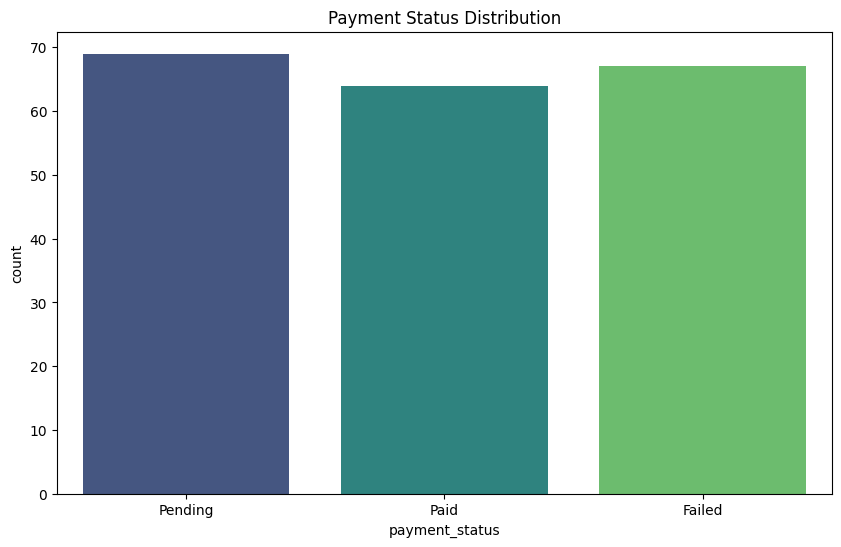

In [83]:
plt.figure(figsize=(10,6))
sns.countplot(x='payment_status', data=df, palette='viridis')
plt.title('Payment Status Distribution')
plt.show()

### Treatment Cost vs Payment Status

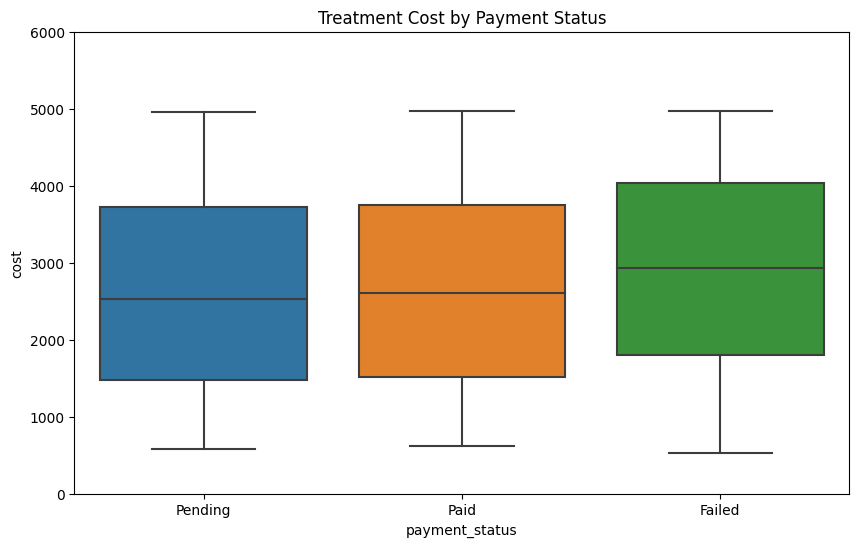

In [84]:
plt.figure(figsize=(10,6))
sns.boxplot(x='payment_status', y='cost', data=df)
plt.title('Treatment Cost by Payment Status')
plt.ylim(0, 6000)
plt.show()

### Insurance Provider Analysis

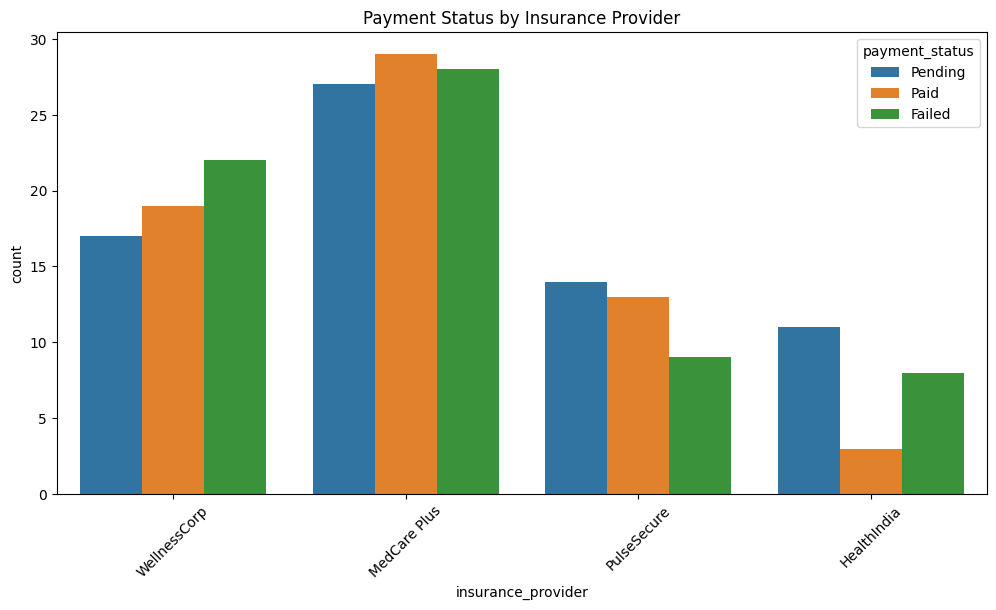

In [85]:
plt.figure(figsize=(12,6))
sns.countplot(x='insurance_provider', hue='payment_status', data=df)
plt.title('Payment Status by Insurance Provider')
plt.xticks(rotation=45)
plt.show()

### Payment Method Analysis

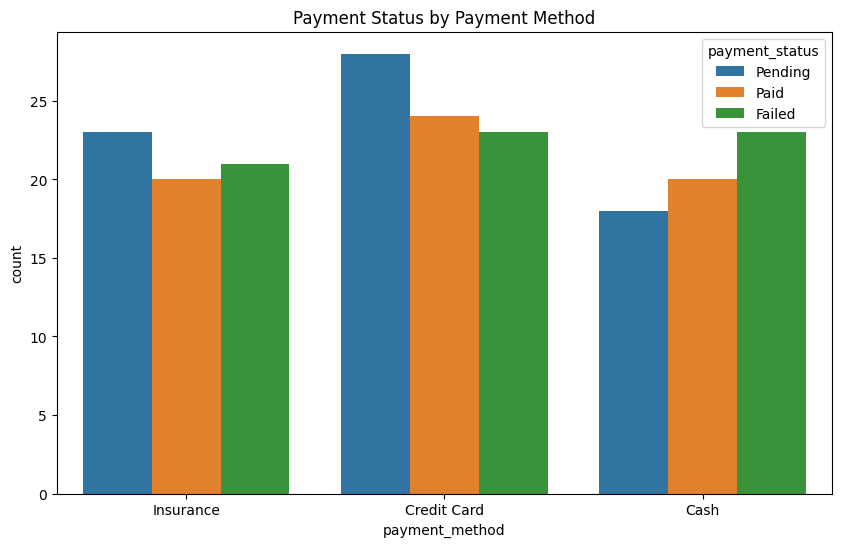

In [86]:
plt.figure(figsize=(10,6))
sns.countplot(x='payment_method', hue='payment_status', data=df)
plt.title('Payment Status by Payment Method')
plt.show()

### Age vs Payment Status

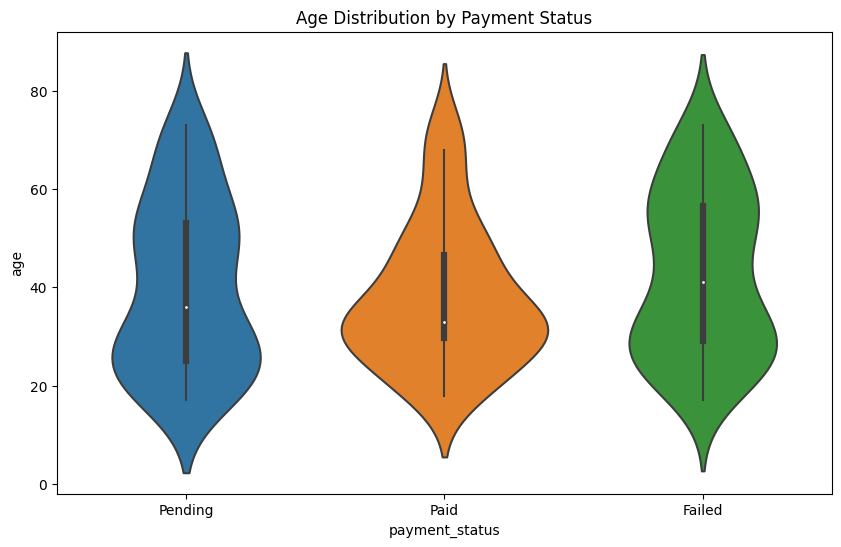

In [87]:
plt.figure(figsize=(10,6))
sns.violinplot(x='payment_status', y='age', data=df)
plt.title('Age Distribution by Payment Status')
plt.show()

## Feature Engineering

In [88]:

df['bill_month'] = df['bill_date'].dt.month
df['bill_dayofweek'] = df['bill_date'].dt.dayofweek


df['high_cost'] = df['cost'].apply(lambda x: 1 if x > 3000 else 0)


insurance_map = {
    'MedCare Plus': 'Private',
    'WellnessCorp': 'Private',
    'HealthIndia': 'Public',
    'PulseSecure': 'Private'
}
df['insurance_type'] = df['insurance_provider'].map(insurance_map)


status_map = {'Completed': 1, 'Scheduled': 0, 'No-show': -1, 'Cancelled': -2}
df['appointment_status'] = df['status'].map(status_map)

## Data Preprocessing

In [95]:

X = df[['cost', 'age', 'payment_method', 'insurance_type', 
        'treatment_type', 'specialization', 'appointment_status',
        'high_cost', 'bill_dayofweek', 'years_experience']]
y = df['payment_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Model Building with Class Weighting

In [90]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {'Failed': 0.9876543209876543, 'Paid': 1.0457516339869282, 'Pending': 0.9696969696969697}


## Random Forest with Class Weighting

In [91]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight=class_weights
    ))
])

# Hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 15, 25],
    'classifier__min_samples_leaf': [1, 2]
}

rf_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='f1_weighted', verbose=1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits


## Gradient Boosting with Sample Weighting

In [92]:
sample_weights = np.array([class_weights[label] for label in y_train])

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['cost', 'age',
                                                   'years_experience']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['payment_method',
                                                   'insurance_type',
                                                   'treatment_type',
                                                   'specialization'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

## Model Evaluation

Random Forest Evaluation:
Accuracy: 0.2000

Classification Report:
              precision    recall  f1-score   support

      Failed       0.24      0.31      0.27        13
        Paid       0.17      0.15      0.16        13
     Pending       0.18      0.14      0.16        14

    accuracy                           0.20        40
   macro avg       0.19      0.20      0.20        40
weighted avg       0.19      0.20      0.19        40



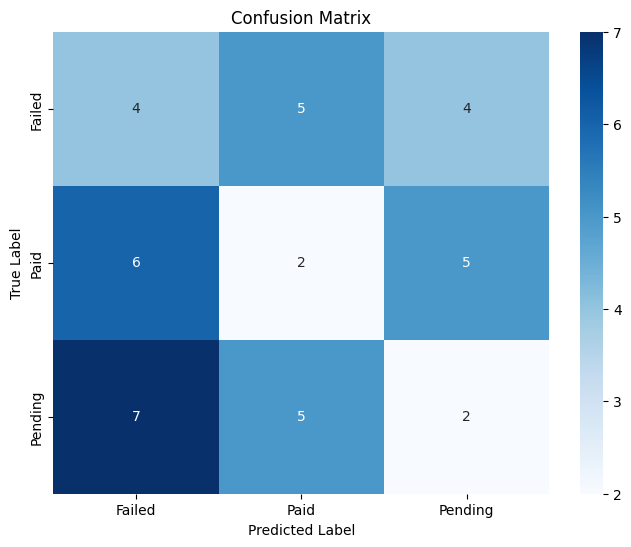


Gradient Boosting Evaluation:
Accuracy: 0.2500

Classification Report:
              precision    recall  f1-score   support

      Failed       0.19      0.23      0.21        13
        Paid       0.23      0.23      0.23        13
     Pending       0.36      0.29      0.32        14

    accuracy                           0.25        40
   macro avg       0.26      0.25      0.25        40
weighted avg       0.26      0.25      0.25        40



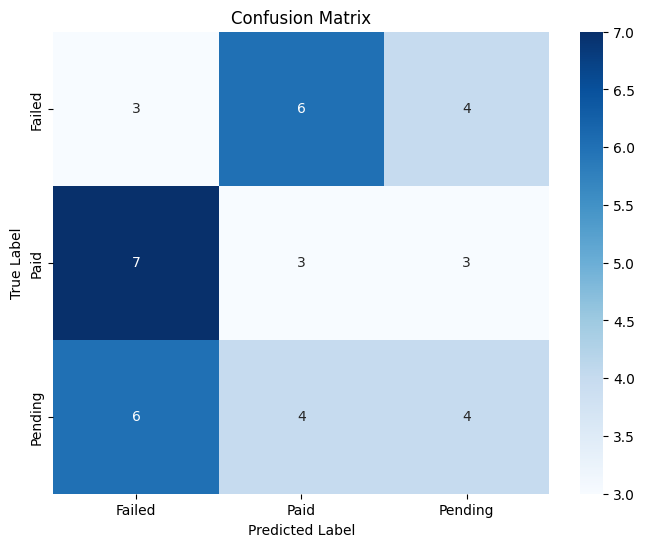

0.25

In [93]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, 
                yticklabels=model.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return accuracy

print("Random Forest Evaluation:")
evaluate_model(best_rf, X_test, y_test)

print("\nGradient Boosting Evaluation:")
evaluate_model(gb_pipeline, X_test, y_test)


### Both the Gradient Boosting and Random Forest models performed poorly on the dataset, with accuracies of 25% and 20%, respectively. All classes showed low precision, recall, and F1-scores, indicating that the models are not effectively distinguishing between the categories. Further improvements are needed through better data quality, feature selection, or trying different algorithms.

<span style="font-size: 24px;">**The process will continue until satisfactory accuracy is achieved.**</span>
